In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/processed/Bacteria_dataset_cleaned.csv")

# Quick overview
print(df.shape)
df.head()

(10710, 22)


,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,...,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,Age,Gender,Bacteria
0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,37.0,0.0,Escherichia coli
1,1.0,0.0,0.0,3.0,0.0,2.0,0.0,2.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,0.0,Morganella morganii
2,1.0,0.0,0.0,3.0,0.0,2.0,0.0,2.0,0.0,0.0,...,0.0,0.0,2.0,2.0,0.0,0.0,0.0,77.0,0.0,Proteus mirabilis
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0,Escherichia coli


In [2]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)})
missing_summary

,Missing Count,Missing Percentage
Diabetes,763,7.12
Hypertension,763,7.12
Hospital_before,763,7.12
Infection_Freq,996,9.30
AMX/AMP,753,7.03
AMC,753,7.03
CZ,753,7.03
FOX,753,7.03
CTX/CRO,753,7.03
IPM,753,7.03


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Diabetes,9947.0,NaN,NaN,NaN,0.2075,0.405537,0.0,0.0,0.0,0.0,1.0
Hypertension,9947.0,NaN,NaN,NaN,0.24902,0.432467,0.0,0.0,0.0,0.0,1.0
Hospital_before,9947.0,NaN,NaN,NaN,0.295466,0.456275,0.0,0.0,0.0,1.0,1.0
Infection_Freq,9714.0,NaN,NaN,NaN,1.514309,1.021972,0.0,1.0,2.0,2.0,3.0
AMX/AMP,9957.0,NaN,NaN,NaN,1.165813,0.976792,0.0,0.0,2.0,2.0,2.0
AMC,9957.0,NaN,NaN,NaN,1.185297,0.973903,0.0,0.0,2.0,2.0,2.0
CZ,9957.0,NaN,NaN,NaN,1.159988,0.978482,0.0,0.0,2.0,2.0,2.0
FOX,9957.0,NaN,NaN,NaN,1.169328,0.976754,0.0,0.0,2.0,2.0,2.0
CTX/CRO,9957.0,NaN,NaN,NaN,1.172944,0.975606,0.0,0.0,2.0,2.0,2.0
IPM,9957.0,NaN,NaN,NaN,1.167018,0.976484,0.0,0.0,2.0,2.0,2.0


In [4]:
clinical_features = [
    "Age",
    "Gender",
    "Diabetes",
    "Hypertension",
    "Hospital_before",
    "Infection_Freq"
]

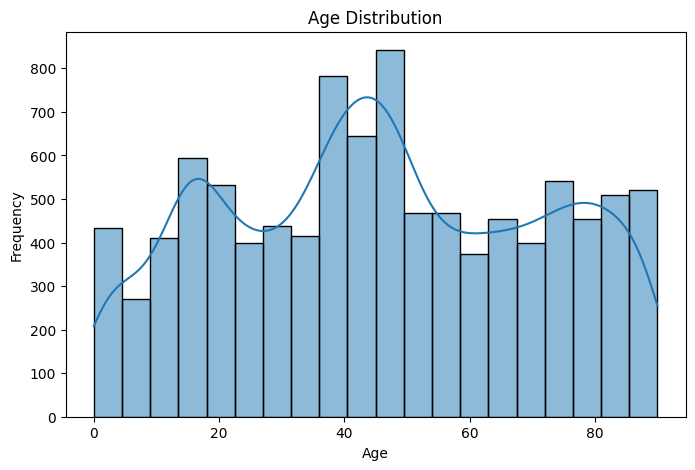

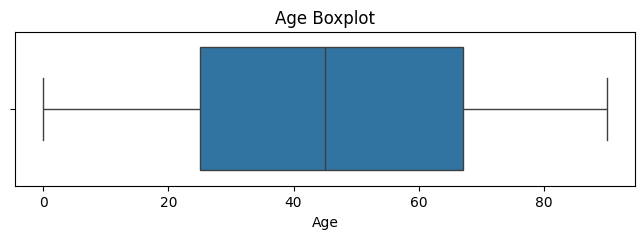

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,2))
sns.boxplot(
    x=df["Age"])
plt.title("Age Boxplot")
plt.show()

In [6]:
def analyze_binary_feature(df, column):
    counts = df[column].value_counts(dropna=False)
    percentages = (
        df[column]
        .value_counts(dropna=False, normalize=True)
        .mul(100)
        .round(2)
    )
    summary = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })
    print(summary)
    plt.figure(figsize=(5,4))
    sns.countplot(
        data=df,
        x=column
    )
    plt.title(f"{column} Distribution")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

        Count  Percentage
Gender                   
0.0      7929       74.03
1.0      2018       18.84
NaN       763        7.12


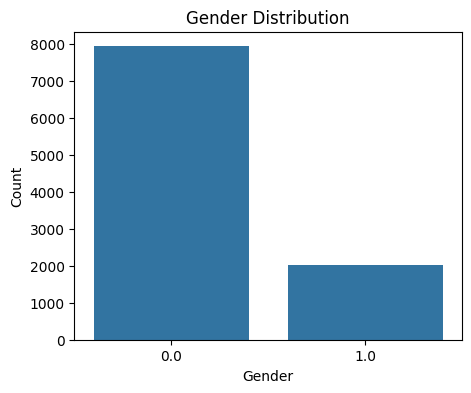

          Count  Percentage
Diabetes                   
0.0        7883       73.60
1.0        2064       19.27
NaN         763        7.12


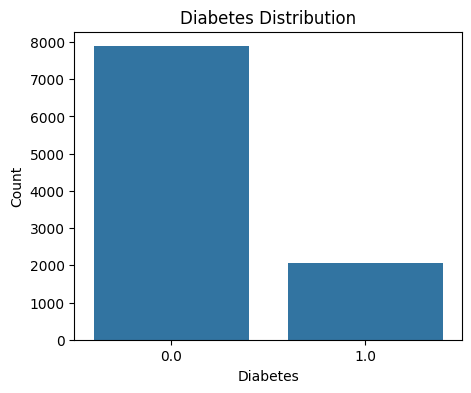

              Count  Percentage
Hypertension                   
0.0            7470       69.75
1.0            2477       23.13
NaN             763        7.12


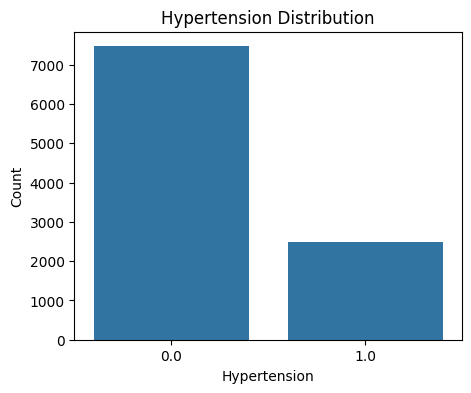

                 Count  Percentage
Hospital_before                   
0.0               7008       65.43
1.0               2939       27.44
NaN                763        7.12


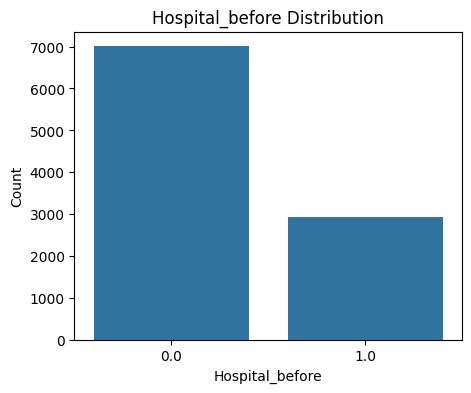

In [7]:
analyze_binary_feature(df, "Gender")
analyze_binary_feature(df, "Diabetes")
analyze_binary_feature(df, "Hypertension")
analyze_binary_feature(df, "Hospital_before")

In [8]:
infection_summary = pd.DataFrame({
    "Count": df["Infection_Freq"].value_counts(dropna=False),
    "Percentage": (
        df["Infection_Freq"]
        .value_counts(dropna=False, normalize=True)
        *100
    ).round(2)})
infection_summary

,Count,Percentage
Infection_Freq,,
2.0,2966,27.69
1.0,2889,26.97
3.0,1963,18.33
0.0,1896,17.70
NaN,996,9.30


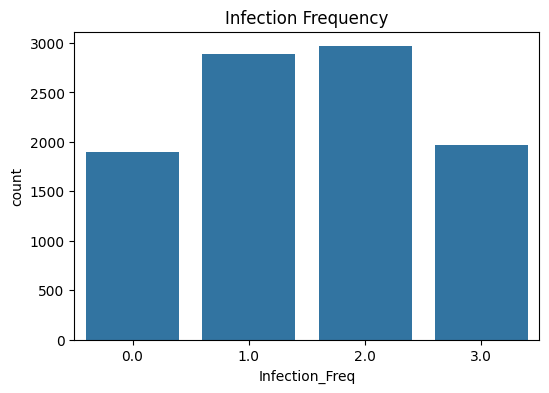

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="Infection_Freq")
plt.title("Infection Frequency")
plt.show()

In [10]:
# Frequency distribution
bacteria_counts = df["Bacteria"].value_counts(dropna=False)

# Percentage distribution
bacteria_percent = (
    df["Bacteria"]
    .value_counts(dropna=False, normalize=True)
    .mul(100)
    .round(2))

bacteria_summary = pd.DataFrame({
    "Count": bacteria_counts,
    "Percentage": bacteria_percent})
bacteria_summary

,Count,Percentage
Bacteria,,
Escherichia coli,6083,56.80
Enterobacteria spp.,997,9.31
NaN,763,7.12
Proteus mirabilis,742,6.93
Klebsiella pneumoniae,702,6.55
Citrobacter spp.,481,4.49
Morganella morganii,305,2.85
Serratia marcescens,256,2.39
Pseudomonas aeruginosa,200,1.87


In [11]:
print("Unique Species :", df["Bacteria"].nunique(dropna=True))
print("Missing Values :", df["Bacteria"].isna().sum())

Unique Species : 9
Missing Values : 763


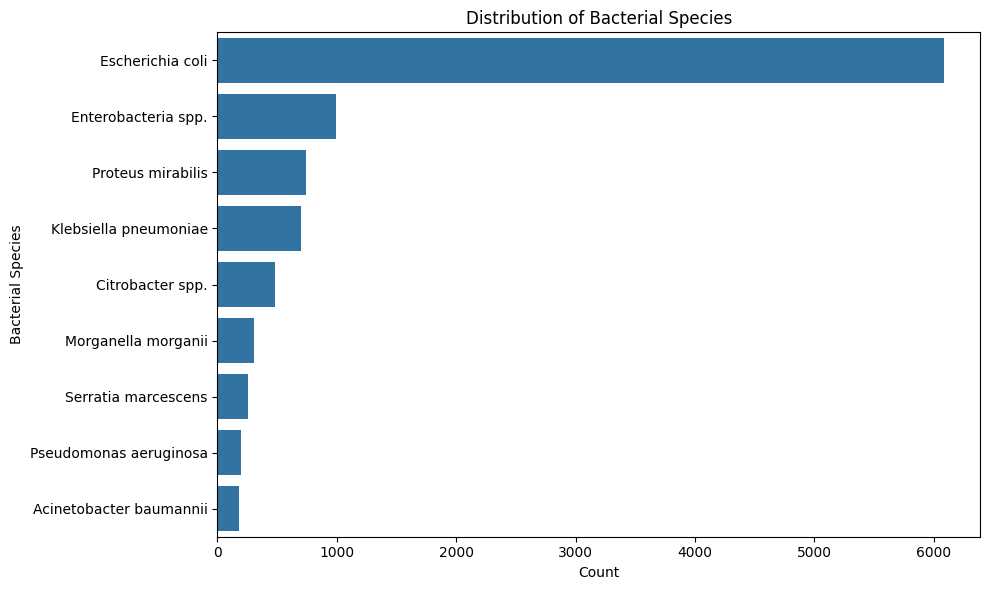

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=bacteria_summary["Count"],
    y=bacteria_summary.index)
plt.title("Distribution of Bacterial Species")
plt.xlabel("Count")
plt.ylabel("Bacterial Species")
plt.tight_layout()
plt.show()

In [13]:
antibiotic_columns = [
    "AMX/AMP",
    "AMC",
    "CZ",
    "FOX",
    "CTX/CRO",
    "IPM",
    "GEN",
    "AN",
    "Acide nalidixique",
    "ofx",
    "CIP",
    "C",
    "Co-trimoxazole",
    "Furanes",
    "colistine"]

In [14]:
def analyze_antibiotic(df, column):
    summary = (
        df[column]
        .value_counts(dropna=False)
        .rename(index={
            0: "Susceptible",
            1: "Intermediate",
            2: "Resistant"
        })
        .rename_axis("Class")
        .reset_index(name="Count")
    )
    summary["Percentage"] = (
        summary["Count"] / len(df) * 100
    ).round(2)
    print(f"\n{'='*60}")
    print(column)
    print(summary)
    plt.figure(figsize=(6,4))
    sns.barplot(
        data=summary,
        x="Class",
        y="Count"
    )
    plt.title(f"{column} Distribution")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
    return summary


AMX/AMP
          Class  Count  Percentage
0     Resistant   5712       53.33
1   Susceptible   4061       37.92
2           NaN    753        7.03
3  Intermediate    184        1.72


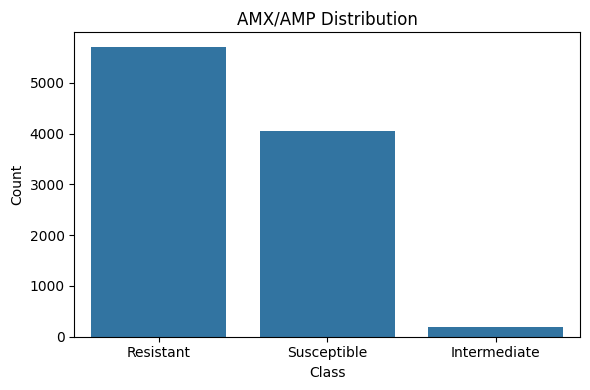


AMC
          Class  Count  Percentage
0     Resistant   5815       54.30
1   Susceptible   3970       37.07
2           NaN    753        7.03
3  Intermediate    172        1.61


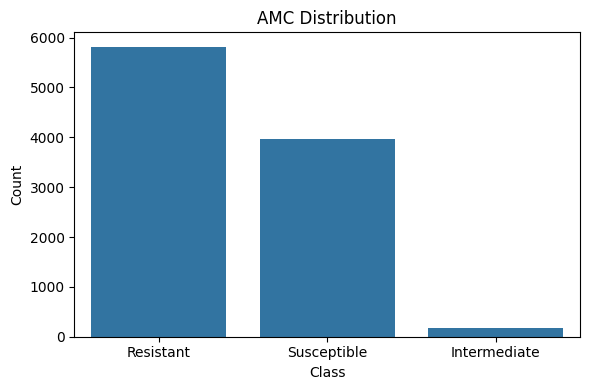


CZ
          Class  Count  Percentage
0     Resistant   5690       53.13
1   Susceptible   4097       38.25
2           NaN    753        7.03
3  Intermediate    170        1.59


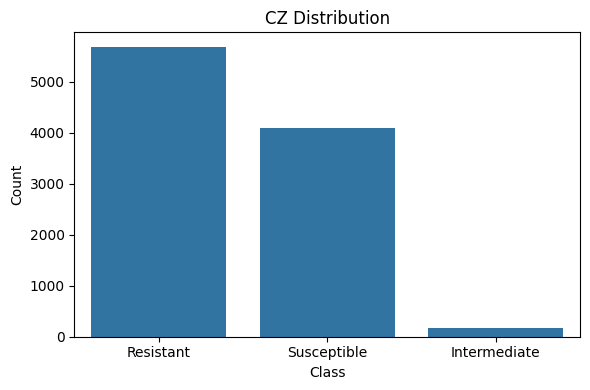


FOX
          Class  Count  Percentage
0     Resistant   5735       53.55
1   Susceptible   4049       37.81
2           NaN    753        7.03
3  Intermediate    173        1.62


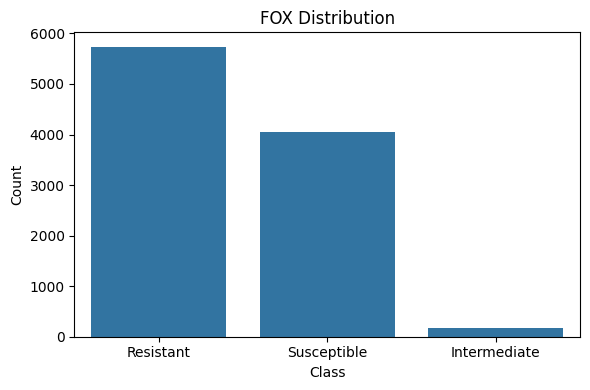


CTX/CRO
          Class  Count  Percentage
0     Resistant   5748       53.67
1   Susceptible   4026       37.59
2           NaN    753        7.03
3  Intermediate    183        1.71


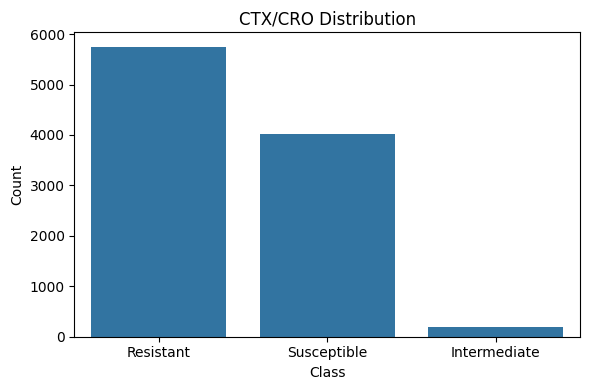


IPM
          Class  Count  Percentage
0     Resistant   5717       53.38
1   Susceptible   4054       37.85
2           NaN    753        7.03
3  Intermediate    186        1.74


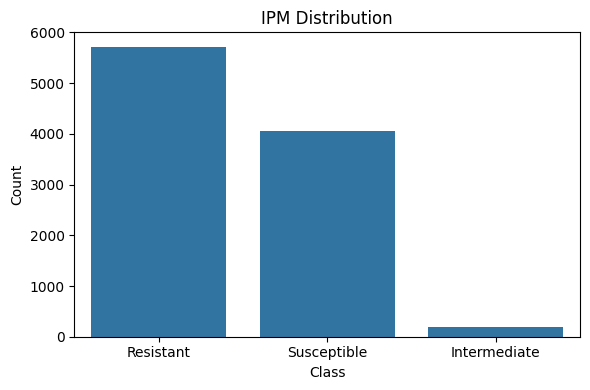


GEN
          Class  Count  Percentage
0   Susceptible   7854       73.33
1     Resistant   1936       18.08
2           NaN    753        7.03
3  Intermediate    167        1.56


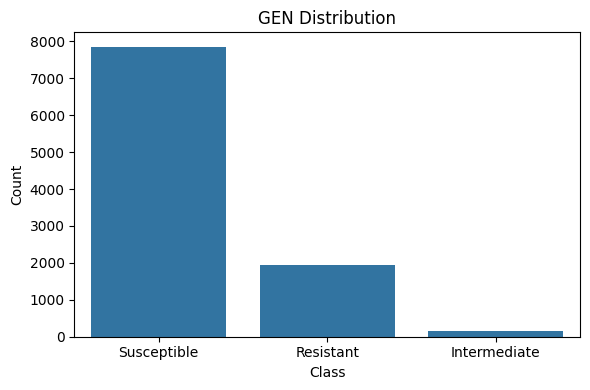


AN
          Class  Count  Percentage
0   Susceptible   7875       73.53
1     Resistant   1905       17.79
2           NaN    753        7.03
3  Intermediate    177        1.65


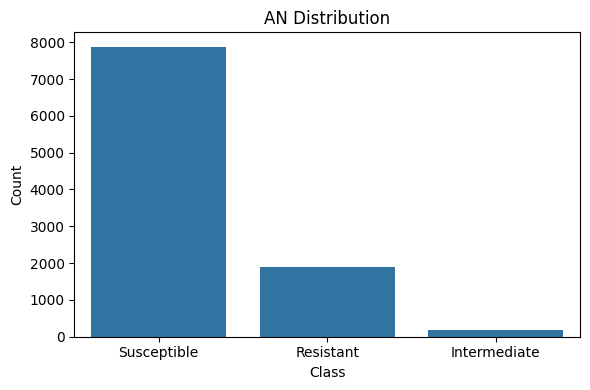


Acide nalidixique
          Class  Count  Percentage
0   Susceptible   8379       78.24
1     Resistant   1388       12.96
2           NaN    753        7.03
3  Intermediate    190        1.77


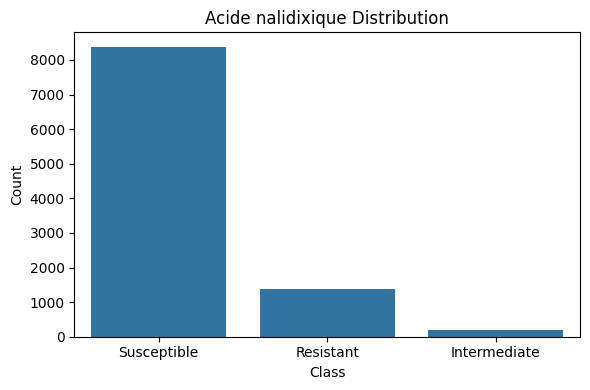


ofx
          Class  Count  Percentage
0   Susceptible   8406       78.49
1     Resistant   1381       12.89
2           NaN    753        7.03
3  Intermediate    170        1.59


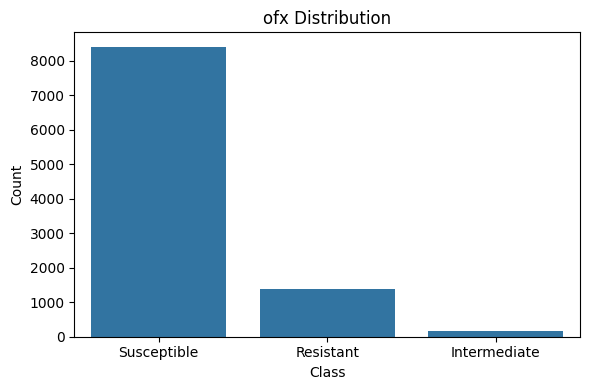


CIP
          Class  Count  Percentage
0   Susceptible   8331       77.79
1     Resistant   1447       13.51
2           NaN    753        7.03
3  Intermediate    179        1.67


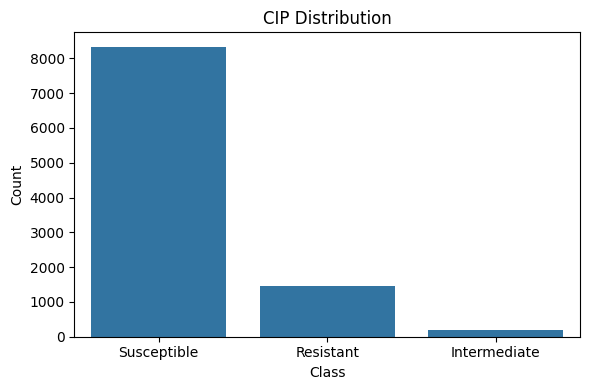


C
          Class  Count  Percentage
0   Susceptible   8390       78.34
1     Resistant   1385       12.93
2           NaN    753        7.03
3  Intermediate    182        1.70


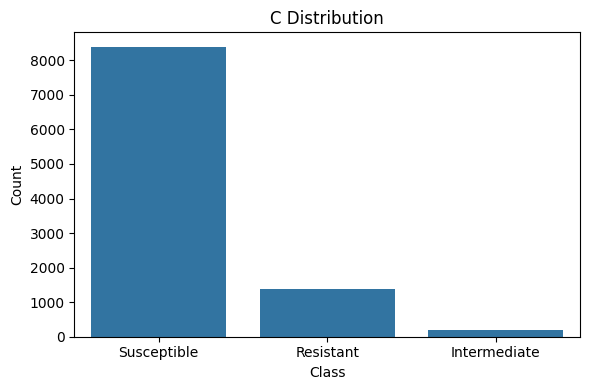


Co-trimoxazole
          Class  Count  Percentage
0   Susceptible   8370       78.15
1     Resistant   1413       13.19
2           NaN    753        7.03
3  Intermediate    174        1.62


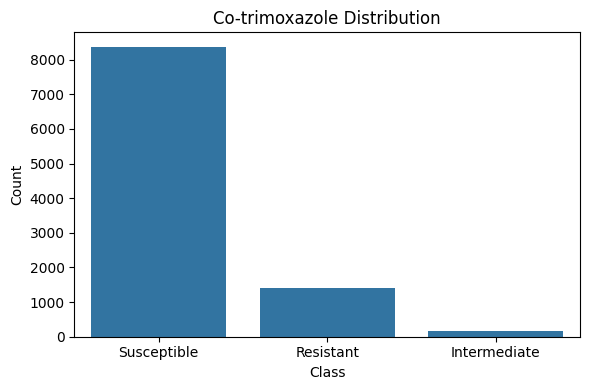


Furanes
          Class  Count  Percentage
0   Susceptible   8457       78.96
1     Resistant   1326       12.38
2           NaN    753        7.03
3  Intermediate    174        1.62


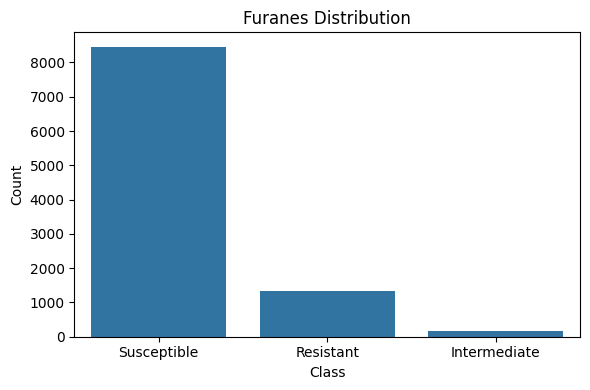


colistine
          Class  Count  Percentage
0   Susceptible   8428       78.69
1     Resistant   1338       12.49
2           NaN    753        7.03
3  Intermediate    191        1.78


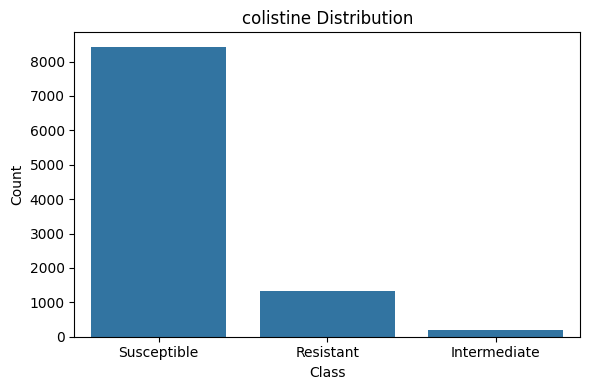

In [15]:
for antibiotic in antibiotic_columns:
    analyze_antibiotic(df, antibiotic)

In [16]:
summary_rows = []
for antibiotic in antibiotic_columns:
    counts = df[antibiotic].value_counts(dropna=False)
    total = len(df)
    summary_rows.append({
        "Antibiotic": antibiotic,
        "Susceptible %":
            round(counts.get(0,0)/total*100,2),
        "Intermediate %":
            round(counts.get(1,0)/total*100,2),
        "Resistant %":
            round(counts.get(2,0)/total*100,2),
        "Missing %":
            round(df[antibiotic].isna().mean()*100,2)})
target_summary = pd.DataFrame(summary_rows)
target_summary

,Antibiotic,Susceptible %,Intermediate %,Resistant %,Missing %
0,AMX/AMP,37.92,1.72,53.33,7.03
1,AMC,37.07,1.61,54.30,7.03
2,CZ,38.25,1.59,53.13,7.03
3,FOX,37.81,1.62,53.55,7.03
4,CTX/CRO,37.59,1.71,53.67,7.03
5,IPM,37.85,1.74,53.38,7.03
6,GEN,73.33,1.56,18.08,7.03
7,AN,73.53,1.65,17.79,7.03
8,Acide nalidixique,78.24,1.77,12.96,7.03
9,ofx,78.49,1.59,12.89,7.03


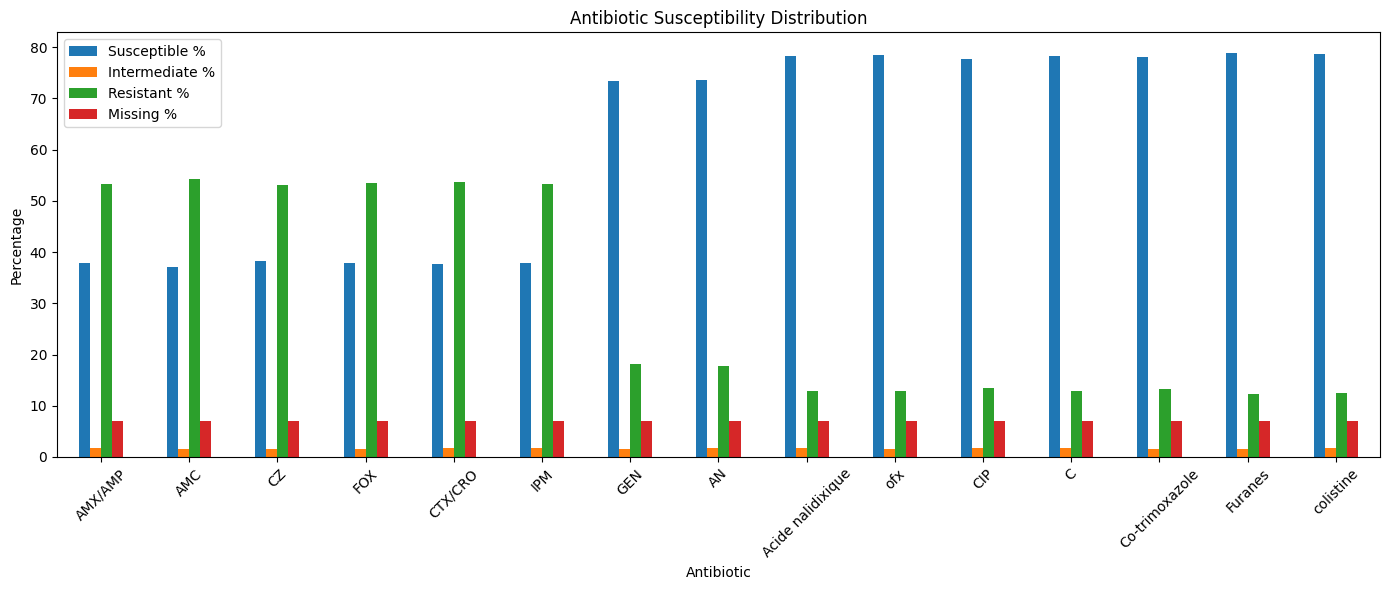

In [17]:
plot_df = target_summary.set_index("Antibiotic")
plot_df.plot(
    kind="bar",
    figsize=(14,6))
plt.ylabel("Percentage")
plt.title("Antibiotic Susceptibility Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
df["Resistant_Count"] = (
    df[antibiotic_columns] == 2).sum(axis=1)

In [19]:
df["Intermediate_Count"] = (
    df[antibiotic_columns] == 1).sum(axis=1)

In [20]:
df["Susceptible_Count"] = (
    df[antibiotic_columns] == 0).sum(axis=1)

In [21]:
df["Missing_Targets"] = (
    df[antibiotic_columns]
    .isna()
    .sum(axis=1))

In [22]:
df[
    [
        "Resistant_Count",
        "Intermediate_Count",
        "Susceptible_Count",
        "Missing_Targets"
    ]].describe()

,Resistant_Count,Intermediate_Count,Susceptible_Count,Missing_Targets
count,10710.000000,10710.000000,10710.000000,10710.000000
mean,4.475817,0.249486,9.220075,1.054622
std,2.622287,1.379430,3.601188,3.835163
min,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,8.000000,0.000000
50%,4.000000,0.000000,10.000000,0.000000
75%,6.000000,0.000000,12.000000,0.000000
max,13.000000,13.000000,15.000000,15.000000


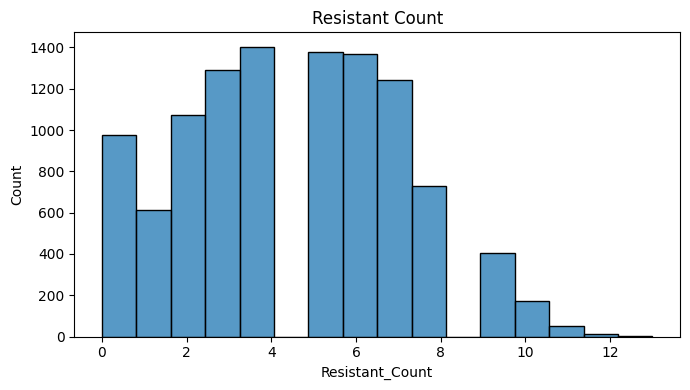

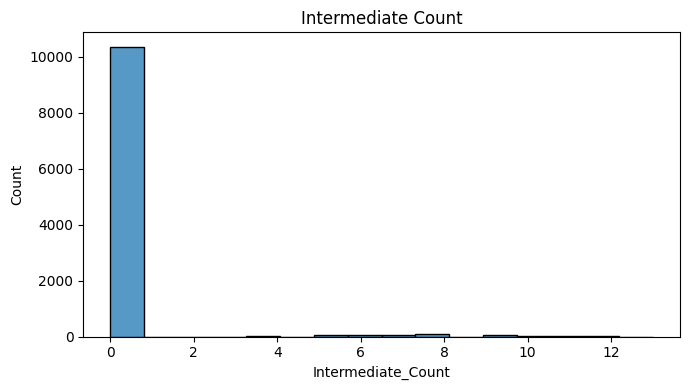

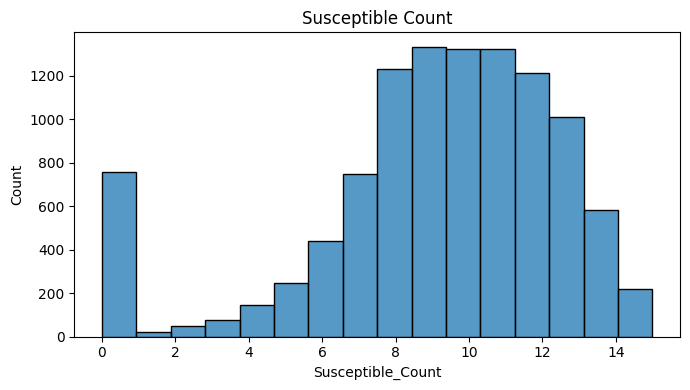

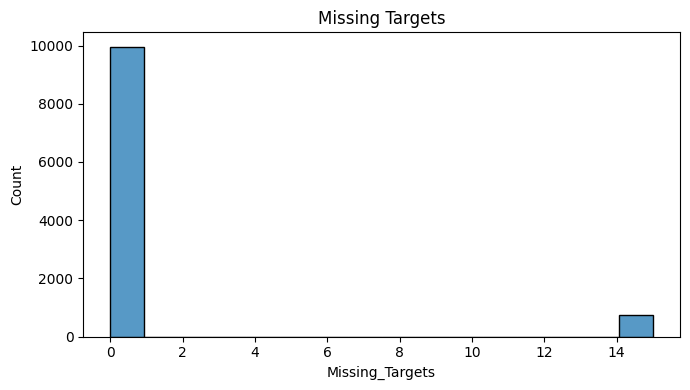

In [23]:
burden_columns = [
    "Resistant_Count",
    "Intermediate_Count",
    "Susceptible_Count",
    "Missing_Targets"]
for column in burden_columns:
    plt.figure(figsize=(7,4))
    sns.histplot(
        data=df,
        x=column,
        bins=16)
    plt.title(column.replace("_"," "))
    plt.tight_layout()
    plt.show()

In [24]:
validation = (
    df["Resistant_Count"]
    + df["Intermediate_Count"]
    + df["Susceptible_Count"]
    + df["Missing_Targets"])
print(validation.value_counts())

15    10710
Name: count, dtype: int64


In [25]:
correlation_matrix = df[antibiotic_columns].corr(method="pearson")

correlation_matrix

,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine
AMX/AMP,1.000000,0.231976,0.226979,0.222704,0.235301,0.236331,0.023096,0.025005,0.070832,0.079692,0.085372,0.072733,0.096603,0.072534,0.063729
AMC,0.231976,1.000000,0.222484,0.218207,0.237527,0.213648,0.008522,0.039757,0.058967,0.069250,0.075911,0.073464,0.073942,0.074546,0.070681
CZ,0.226979,0.222484,1.000000,0.230603,0.227007,0.216337,0.017951,0.010813,0.065607,0.054661,0.079861,0.069253,0.087162,0.073526,0.076250
FOX,0.222704,0.218207,0.230603,1.000000,0.224870,0.220033,0.030197,0.034125,0.071066,0.063854,0.068603,0.072975,0.075175,0.073897,0.069247
CTX/CRO,0.235301,0.237527,0.227007,0.224870,1.000000,0.235789,0.017832,0.017804,0.072517,0.059702,0.086504,0.070453,0.077189,0.075453,0.075107
IPM,0.236331,0.213648,0.216337,0.220033,0.235789,1.000000,0.042818,0.020476,0.067530,0.078162,0.062986,0.079308,0.094788,0.062139,0.068761
GEN,0.023096,0.008522,0.017951,0.030197,0.017832,0.042818,1.000000,0.046933,0.046529,0.037723,0.047313,0.029478,0.025748,0.031510,0.042101
AN,0.025005,0.039757,0.010813,0.034125,0.017804,0.020476,0.046933,1.000000,0.045977,0.034345,0.018196,0.024800,0.038689,0.027562,0.050290
Acide nalidixique,0.070832,0.058967,0.065607,0.071066,0.072517,0.067530,0.046529,0.045977,1.000000,0.056272,0.060474,0.073909,0.062647,0.063610,0.068925
ofx,0.079692,0.069250,0.054661,0.063854,0.059702,0.078162,0.037723,0.034345,0.056272,1.000000,0.067450,0.075999,0.068620,0.055724,0.071174


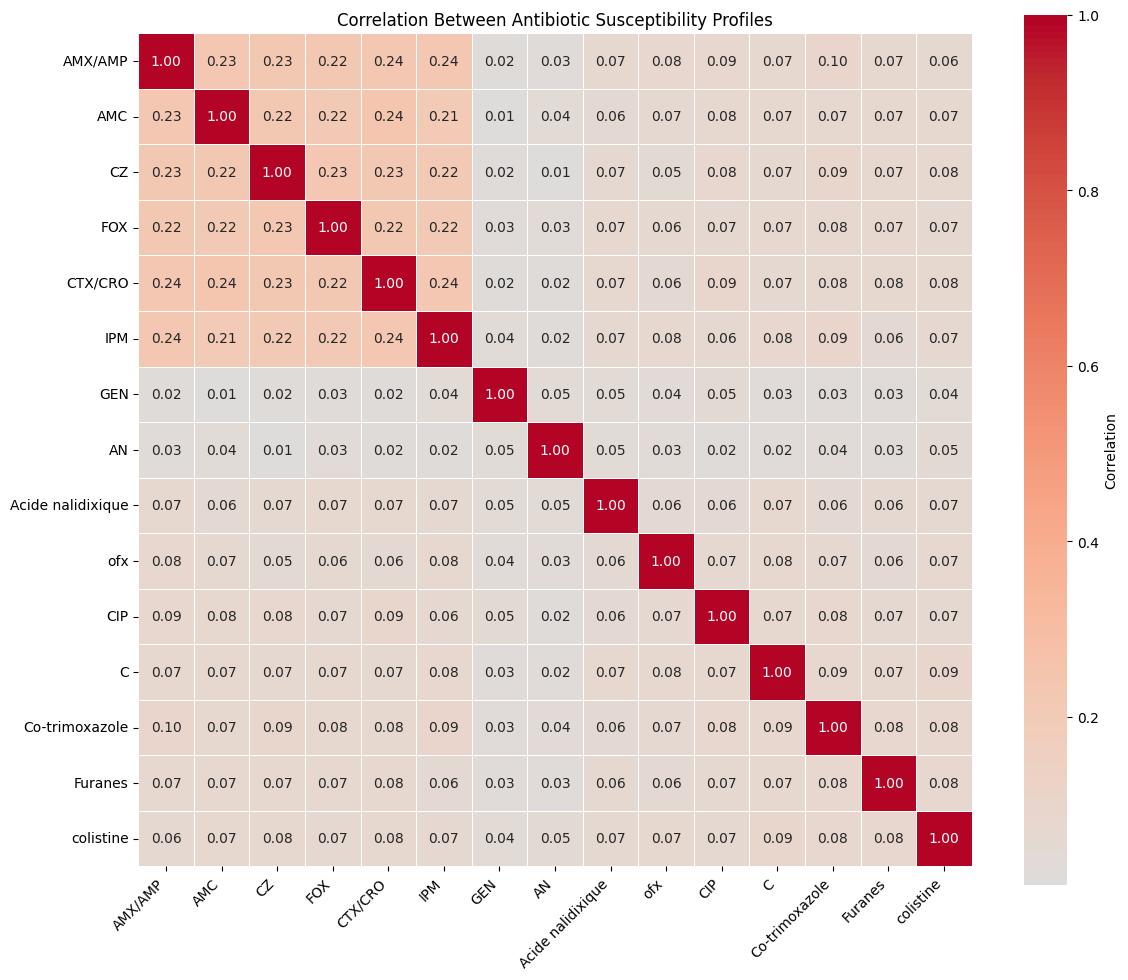

In [28]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Between Antibiotic Susceptibility Profiles")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [29]:
feature_target_corr = df[
    clinical_features + antibiotic_columns
].corr(method="pearson")

feature_target_corr = feature_target_corr.loc[
    clinical_features,
    antibiotic_columns
]

feature_target_corr

,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine
Age,-0.008286,-0.002593,0.003436,0.001392,0.001502,0.004316,0.009664,0.014215,-0.011413,0.008311,-0.008289,0.008289,0.014655,0.001167,0.005428
Gender,0.013474,0.000182,-0.002245,0.021430,0.010004,0.011112,-0.007430,0.012154,0.001752,0.019539,-0.011628,0.005575,0.006537,-0.002734,0.019897
Diabetes,0.003554,-0.001221,-0.004603,-0.005088,-0.006337,0.009574,-0.013185,0.004078,-0.001699,0.012428,-0.005296,-0.001440,0.022047,0.013585,0.038741
Hypertension,-0.011812,0.005203,0.003222,0.010685,-0.004184,0.010623,0.014858,0.018823,-0.019176,0.000873,-0.004997,-0.027382,-0.000930,0.003313,-0.001080
Hospital_before,0.009609,0.002113,-0.010259,-0.009123,-0.008736,0.007071,0.001319,-0.000216,0.010417,-0.004133,-0.004168,0.007373,-0.014388,0.004233,-0.002572
Infection_Freq,0.003622,0.003592,0.003158,-0.004129,0.000985,-0.010189,-0.011720,0.005486,-0.011671,-0.017997,-0.006446,0.001753,0.010981,-0.004979,0.002603


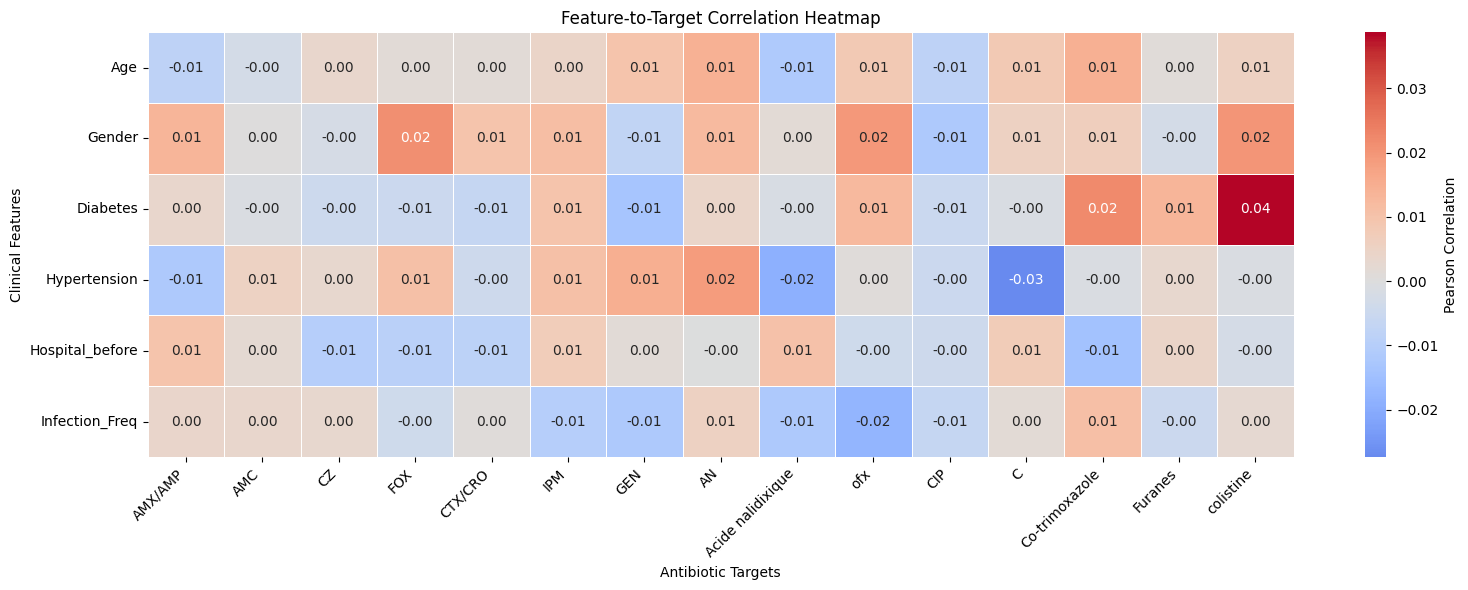

In [30]:
plt.figure(figsize=(16,6))

sns.heatmap(
    feature_target_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title("Feature-to-Target Correlation Heatmap")

plt.xlabel("Antibiotic Targets")
plt.ylabel("Clinical Features")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()